In [22]:
import os
import random
import cv2
import matplotlib.pyplot as plt

In [10]:
df = pd.read_excel(r"F:\Github\bender-gestalt-analysis\data\raw\original_excel\نسخة_من_إختبار_بندرالجديد_الردود.xlsx")
df.head()

,رقم الحالة,الاسم,النوع,الصف الدراسي,العمر,التسلسل,موضع الرسم,المسافة بين رسمين,الاتصال أو التصادم,استخدام الهامش,تغيير موضع الورقة,التغيرات في الجشطالت,ملاحظات دالة بشكل عام,التصنيفات المرضية,التعليق العام
0,1,ياسين محمود علي حسن,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, التغير في الانحناءات",لا يوجد,سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
1,2,عمرو احمد محمد فتحي,ذكر,الرابع الإبتدائي,9,تسلسل منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق - التغير في الانحناءات, التغير ...",إعادة رسم الأجزاء (خطوط ثقيلة),سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...
2,3,محمد سيد البدري عبد المطلب,ذكر,الرابع الإبتدائي,9,تسلسل غير منظم,لا,من 0.75 إلى 1.25 سم,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, صعوبات التقاطع, التغير في الان...","اندفاع وسرعة في الرسم, المداومة",سوي,المفحوص بشكل عام سوي ويتمتع بمستوى متوسط من ال...
3,4,عدي هاني سيد محمد,ذكر,الرابع الإبتدائي,10,تسلسل غير منظم,لا,مسافة صغيرة جداً,لا يوجد تداخل,لا,لا,"صعوبات الإغلاق, صعوبات التقاطع, التغير في الان...",المداومة,سوي,المفحوص بشكل عام سوي ويتمتع بقدرة متوسطة على ا...
4,5,عمر حاتم عمر الفاروق,ذكر,الرابع الإبتدائي,11,تسلسل غير منظم,لا,مسافة صغيرة جداً,تصادم أو نزعة إليه,لا,لا,"التغير في الانحناءات, صعوبة رسم الأشكال المتداخلة",لا يوجد,سوي,المفحوص بشكل عام سوي ويتمتع بالقدرة على التأزر...


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   رقم الحالة             89 non-null     int64 
 1   الاسم                  89 non-null     object
 2   النوع                  89 non-null     object
 3   الصف الدراسي           89 non-null     object
 4   العمر                  89 non-null     int64 
 5   التسلسل                89 non-null     object
 6   موضع الرسم             89 non-null     object
 7   المسافة بين رسمين      89 non-null     object
 8   الاتصال أو التصادم     89 non-null     object
 9   استخدام الهامش         89 non-null     object
 10  تغيير موضع الورقة      89 non-null     object
 11  التغيرات في الجشطالت   89 non-null     object
 12  ملاحظات دالة بشكل عام  89 non-null     object
 13  التصنيفات المرضية      89 non-null     object
 14  التعليق العام          89 non-null     object
dtypes: int64(2), object(13)
m

In [5]:
for col in df.columns:
  print("Column:",col)
  print(df[col].unique())
  print("-"*50)

Column: رقم الحالة
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]
--------------------------------------------------
Column: الاسم
['ياسين محمود علي حسن' 'عمرو احمد محمد فتحي' 'محمد سيد البدري عبد المطلب'
 'عدي هاني سيد محمد' 'عمر حاتم عمر الفاروق'
 'عبد الحميد محمود عبد الحميد محمد' 'ياسين عمرو سيد عبد الغفور'
 'سادن وعيد محمد دهب' 'حسن حسام حسن امين' 'محمود مصطفى محمود حسن'
 'محمد محمود محمد احمد زناتي' 'محمد حسين احمد' 'محمد احمد مجدي احمد'
 'رفيده ابو المجد محمد ابو المجد' 'فاطمه كريم خالد علي يوسف'
 'ليال محمد عبد الفتاح عثمان' 'عنود سامح سعيد عواد'
 'يسرا احمد عبد الغني احمد خطاب' 'كنزي سيد هاشم احمد' 'فرح خالد محسن علي'
 'سما محمد يوسف محمد محمد' 'روان محمد ابراهيم جابر حسنين'
 'اسراء جمعه محمد احمد' 'رهف محمود محمد دندراوي' 'انس محمد فوزي زكي'
 'اياد عمرو ا

- The ID and Name of Students are irrelevant data we need to drop
- [النوع, الصف الدراسي, العمر] in phase of ML
- Core Features for Images [ ,التسلسل,موضع الرسم , المسافة بين الرسمتين,الاتصال والتصادم, استخدام الهوامش , تغيير موضع الورقة] --> for each feature we need to Classify (Binary or Categorical)
- [التغيرات في الجشطالت] --> Very important column that is a multi-label

In [ ]:
df.isnull().sum()
df['التصنيفات المرضية'].value_counts() # if there biased in model or not

التصنيفات المرضية
سوي              83
العصاب            3
التخلف العقلي     2
سوي               1
Name: count, dtype: int64

<Axes: xlabel='التصنيفات المرضية'>

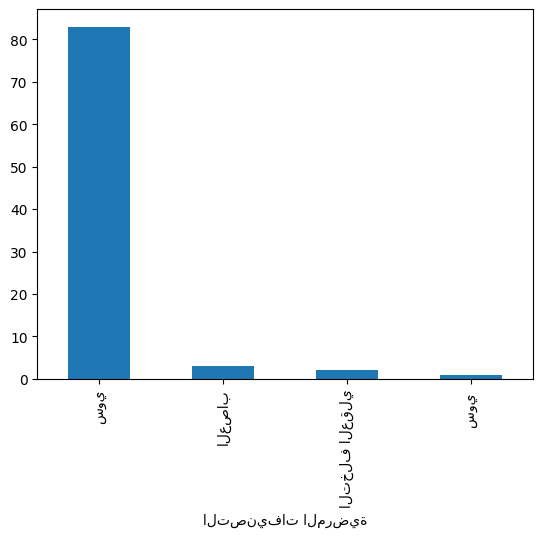

In [28]:
df['التصنيفات المرضية'].value_counts().plot(kind='bar')

## **One Image Represented**

(np.float64(-0.5), np.float64(1240.5), np.float64(1754.5), np.float64(-0.5))

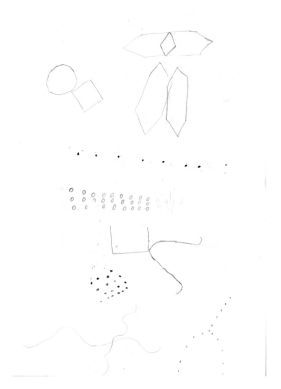

In [25]:
img = cv2.imread(r"F:\Github\bender-gestalt-analysis\data\raw\images\page-0001.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

In [29]:
img.shape

(1755, 1241, 3)